In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Just to ignore warnings

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import uproot
from variables_calculator import variables_calculator

import warnings
warnings.filterwarnings("ignore")

## Higgs signal classification

In [2]:
# Now we check for the Higgs signal
file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 1)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

signal = pd.merge(jets_data, lepton_data, on = "event_1")
signal = signal.drop(columns = ["event_1"])

# And the noise
file = "/tf/Higgs-Boson-LHC-Collision-Detector/bgd240zh.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 0)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

noise1 = pd.merge(jets_data, lepton_data, on = "event_1")
noise1 = noise1.drop(columns = ["event_1"])

# Noise 2

file = "/tf/Higgs-Boson-LHC-Collision-Detector/bgd365eez.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 0)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

noise2 = pd.merge(jets_data, lepton_data, on = "event_1")
noise2 = noise2.drop(columns = ["event_1"])

noise = pd.concat([noise1, noise2])

signal = signal.sample(n = 2*len(noise), random_state = 5).reset_index(drop = True)

val = pd.concat([signal, noise])

# Now we can create the subsets:
X_val = val.drop(columns = ["label"])
y_val = val["label"]

X_val = X_val.sample(frac = 1, random_state = 5).reset_index(drop = True)
y_val = y_val.sample(frac = 1, random_state = 5).reset_index(drop = True)

# And we stardardize the data:

scaler = StandardScaler()

X_val = scaler.fit_transform(X_val)

# Check the sizes
print("Validation size:", len(X_val))

Validation size: 2550


In [3]:
signal.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
0,283.082214,3,1.603055,0.814205,6.544251,135.087875,-2.233615,0.250926,1.421470,0.651507,97.000153,1,91.582001
1,185.970169,3,41.329166,0.146658,42.304386,31.194227,-1.139107,0.790805,0.082970,0.567366,83.347824,1,88.393929
2,279.098114,3,2.059965,0.865256,135.853958,5.667910,0.211994,-2.439807,2.404117,-2.597239,102.634483,1,90.601875
3,246.619293,3,36.361500,-2.640416,51.606480,58.326920,0.932145,-0.526349,2.945787,-2.538333,97.177391,1,90.668182
4,218.112137,3,16.793482,-0.117597,79.480927,21.542896,1.061978,-0.773855,0.173839,-0.004003,87.401398,1,89.580544


In [4]:
noise.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
0,172.937119,3,0.557494,-1.934222,69.766052,22.373613,-0.521332,1.403592,-1.065475,-2.280855,99.201279,0,85.794327
1,180.318436,3,2.887091,1.928385,75.999969,76.263161,-0.315505,-0.189763,-0.921315,1.856216,150.053299,0,92.016815
2,172.628799,3,9.632188,0.661179,1.443408,81.739647,-0.121949,0.460956,1.381099,-0.067612,15.762868,0,91.779892
3,183.632690,3,1.840503,2.749444,91.454391,90.393394,0.273698,-0.325426,0.896851,-2.206637,190.033447,0,90.173676
4,169.134064,3,0.999657,-2.519436,55.062290,67.079384,0.289985,0.749383,1.660282,-2.232917,116.521919,0,90.313919


In [5]:
val.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
0,283.082214,3,1.603055,0.814205,6.544251,135.087875,-2.233615,0.250926,1.421470,0.651507,97.000153,1,91.582001
1,185.970169,3,41.329166,0.146658,42.304386,31.194227,-1.139107,0.790805,0.082970,0.567366,83.347824,1,88.393929
2,279.098114,3,2.059965,0.865256,135.853958,5.667910,0.211994,-2.439807,2.404117,-2.597239,102.634483,1,90.601875
3,246.619293,3,36.361500,-2.640416,51.606480,58.326920,0.932145,-0.526349,2.945787,-2.538333,97.177391,1,90.668182
4,218.112137,3,16.793482,-0.117597,79.480927,21.542896,1.061978,-0.773855,0.173839,-0.004003,87.401398,1,89.580544


80/80 [==============================] - 1s 3ms/step


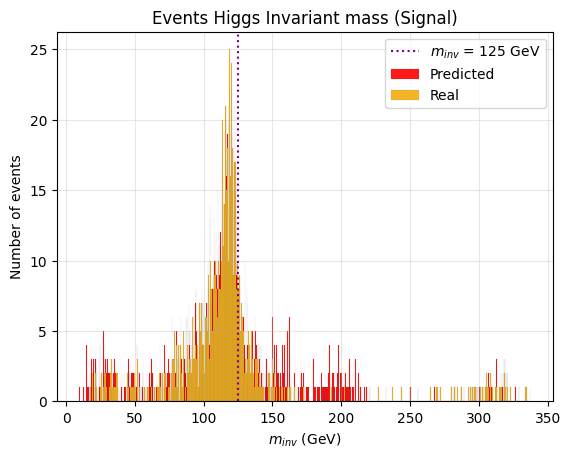

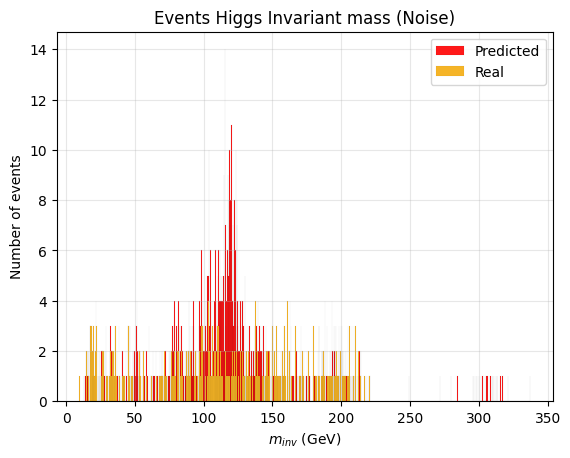

In [6]:
# Check the predictions
model = keras.models.load_model("/tf/Higgs-Boson-LHC-Collision-Detector/Trials-ANN/ResNet-SnB-Higgs_B-Classificator-Final.keras")

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

real_data = val
order = ['PRI_jet_all_pt', 'PRI_jet_num', 'PRI_met', 'PRI_met_phi',
       'PRI_jet_leading_pt', 'PRI_jet_subleading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_subleading_eta', 'PRI_jet_leading_phi',
       'PRI_jet_subleading_phi', 'DER_mass_jet_jet', 'label', 'DER_mass_lep']
real_data = real_data.reindex(columns = order)
predicted_data = real_data.drop(columns = ["label"])
predicted_data["label"] = y_pred_classes

df_predicted_signal = predicted_data[predicted_data["label"] != 0].copy()
df_real_signal = real_data[real_data["label"] != 0].copy()

df_predicted_background = predicted_data[predicted_data["label"] == 0].copy()
df_real_background = real_data[real_data["label"] == 0].copy()

sns.histplot(df_predicted_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 125, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 125 GeV")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Signal)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Noise)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

80/80 [==============================] - 0s 3ms/step


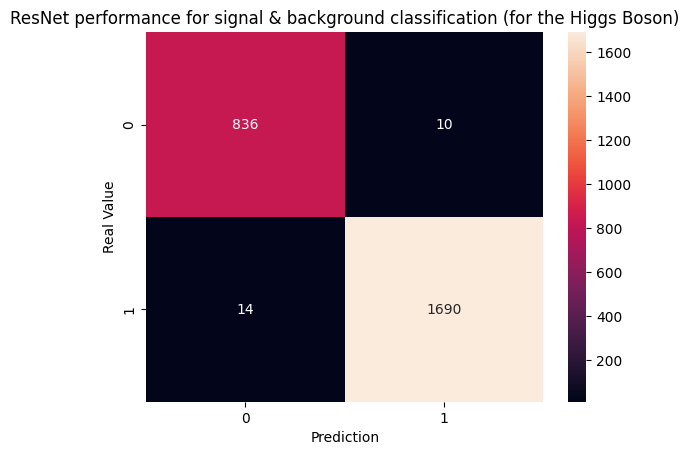

In [7]:
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_pred_classes, y_val)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "rocket")
plt.title("ResNet performance for signal & background classification (for the Higgs Boson)")
plt.xlabel("Prediction")
plt.ylabel("Real Value")
plt.show()

In [8]:
loss, accuracy, precision, auc, auc_1 = model.evaluate(X_val, y_val, verbose = 1)

print(f"Test Loss: {loss:}")
print(f"Test Accuracy: {accuracy:}")

80/80 [==============================] - 3s 5ms/step - loss: 0.0720 - accuracy: 0.9906 - precision: 0.9918 - auc: 0.9956 - auc_1: 0.9957
Test Loss: 0.07200542837381363
Test Accuracy: 0.9905882477760315


### Notes

#### Metrics for deterministic 0/1 predictions

- False negatives and false positives are samples that were incorrectly classified
- True negatives and true positives are samples that were correctly classified
- Accuracy is the percentage of examples correctly classified $\rightarrow \frac{true \ samples}{total \ samples}$
- Precision is the percentage of predicted positives that were correctly classified $\rightarrow \frac{true \ positives}{true \ positives + false \ positives}$
- Recall is the percentage of actual positives that were correctly classified $\rightarrow \frac{true \ positives}{true \ positives + false \ negatives}$

#### Other metrices

The following metrics take into account all possible choices of thresholds $t$.

- AUC refers to the Area Under the Curve of a Receiver Operating Characteristic curve (ROC-AUC). This metric is equal to the probability that a classifier will rank a random positive sample higher than a random negative sample.
- AUPRC refers to Area Under the Curve of the Precision-Recall Curve. This metric computes precision-recall pairs for different probability thresholds.

References: 
https://www.tensorflow.org/tutorials/structured_data/imbalanced_data#metrics_for_deterministic_01_predictions
https://www.tensorflow.org/tutorials/structured_data/imbalanced_data#other_metrices